# Test file for CICIDS2018 model creation and analysis

### 1. Data loading

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta

pd.options.display.max_rows = 80

In [2]:
import pandas as pd
import os

# read data

df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-IDS2018.csv')
df = df.iloc[:, :-4]


/tmp/ipykernel_3096534/1666283378.py:6: DtypeWarning: Columns (80,81,83) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-IDS2018.csv')


### 2. Data exploration

In [3]:
from IPython.display import display
display(df.head())

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,01/03/2018 08:17:11,115307855,5,0,0.0,0.0,0.0,0.0,...,0,1812348.0,0.0,1812348.0,1812348.0,56700000.0,6.010058e+06,61000000.0,52500000.0,Benign
1,0,0,01/03/2018 08:20:07,60997457,2,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,61000000.0,0.000000e+00,61000000.0,61000000.0,Benign
2,67,17,01/03/2018 08:17:18,61149019,5,0,1500.0,0.0,300.0,300.0,...,8,3530939.0,0.0,3530939.0,3530939.0,19200000.0,1.250000e+07,32600000.0,7999725.0,Benign
3,0,0,01/03/2018 08:22:09,60997555,2,0,0.0,0.0,0.0,0.0,...,0,0.0,0.0,0.0,0.0,61000000.0,0.000000e+00,61000000.0,61000000.0,Benign
4,0,0,01/03/2018 08:24:11,61997503,3,0,0.0,0.0,0.0,0.0,...,0,999909.0,0.0,999909.0,999909.0,61000000.0,0.000000e+00,61000000.0,61000000.0,Benign


In [4]:
print('Cantidad de Filas y columnas:',df.shape)
print('Nombre columnas:',df.columns)

Cantidad de Filas y columnas: (16232943, 80)
Nombre columnas: Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag C

In [5]:
# convert label to string, timestamp to datetime and the others to float
df['Label'] = df['Label'].astype(str)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M:%S')
for col in df.columns[1:]:
    if col != 'Label' and col != 'Timestamp':
        df[col] = df[col].astype(float)

In [7]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Src Port,3540241.0,31875.725738,1.948902e+04,10.000000,14729.000000,31789.000000,48846.000000,6.553500e+04
Dst Port,3540241.0,16416.323047,2.038958e+04,10.000000,80.000000,6434.000000,30906.000000,6.553500e+04
Protocol,3540241.0,7.759312,4.032029e+00,6.000000,6.000000,6.000000,6.000000,1.700000e+01
Flow Duration,3540241.0,348760.158138,2.748282e+06,1.000000,343.000000,1229.000000,52351.000000,1.199995e+08
Total Fwd Packet,3540241.0,22.661563,6.852967e+01,1.000000,1.000000,2.000000,22.000000,2.003800e+04
Total Bwd packets,3540241.0,29.387113,1.010743e+02,0.000000,2.000000,2.000000,23.000000,1.102100e+04
Total Length of Fwd Packet,3540241.0,1878.353584,5.530137e+04,0.000000,0.000000,90.000000,474.000000,2.605270e+07
Total Length of Bwd Packet,3540241.0,23421.268448,1.282813e+05,0.000000,0.000000,122.000000,4986.000000,1.421599e+07
Fwd Packet Length Max,3540241.0,150.079726,3.216338e+02,0.000000,0.000000,45.000000,114.000000,1.476000e+03
Fwd Packet Length Min,3540241.0,10.940842,3.996782e+01,0.000000,0.000000,0.000000,0.000000,1.472000e+03


### 3. Data cleaning

In [6]:
# Duplicate values
duplicates = df.duplicated()
print(f'There are {duplicates.sum()} duplicated rows in the dataset. Total shape: {df.shape}')
df.drop_duplicates(inplace=True)
print(f'Duplicated rows have been removed. New shape: {df.shape}')


There are 433195 duplicated rows in the dataset. Total shape: (16232943, 80)
Duplicated rows have been removed. New shape: (15799748, 80)


In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Flow Byts/s    58342
dtype: int64


In [8]:
# Checking for infinity values
numeric_cols = df.select_dtypes(include = np.number).columns
inf_count = np.isinf(df[numeric_cols]).sum()
print(inf_count[inf_count > 0])

Flow Byts/s    35954
Flow Pkts/s    94296
dtype: int64


In [9]:
# Replacing any infinite values (positive or negative) with NaN (not a number)
print(f'Initial missing values: {df.isna().sum().sum()}')

df.replace([np.inf, -np.inf], np.nan, inplace = True)

print(f'Missing values after processing infinite values: {df.isna().sum().sum()}')

missing = df.isna().sum()
print(missing.loc[missing > 0])

Initial missing values: 58342
Missing values after processing infinite values: 188592
Flow Byts/s    94296
Flow Pkts/s    94296
dtype: int64


In [10]:
# Calculating missing value percentage in the dataset
mis_per = (missing / len(df)) * 100
mis_table = pd.concat([missing, mis_per.round(2)], axis = 1)
mis_table = mis_table.rename(columns = {0 : 'Missing Values', 1 : 'Percentage of Total Values'})

print(mis_table.loc[mis_per > 0])

             Missing Values  Percentage of Total Values
Flow Byts/s           94296                         0.6
Flow Pkts/s           94296                         0.6


In [11]:
med_flow_bytes = df['Flow Byts/s'].median()
med_flow_packets = df['Flow Pkts/s'].median()

print('Median of Flow Bytes/s: ', med_flow_bytes)
print('Median of Flow Packets/s: ', med_flow_packets)

Median of Flow Bytes/s:  840.8243735104226
Median of Flow Packets/s:  115.62030292519366


In [12]:
# Filling missing values with median
df['Flow Byts/s'].fillna(med_flow_bytes, inplace = True)
df['Flow Pkts/s'].fillna(med_flow_packets, inplace = True)

print('Number of \'Flow Bytes/s\' missing values:', df['Flow Byts/s'].isna().sum())
print('Number of \'Flow Packets/s\' missing values:', df['Flow Pkts/s'].isna().sum())

Number of 'Flow Bytes/s' missing values: 0
Number of 'Flow Packets/s' missing values: 0


/tmp/ipykernel_3096534/3183067787.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Flow Byts/s'].fillna(med_flow_bytes, inplace = True)
/tmp/ipykernel_3096534/3183067787.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [13]:
# save to csv
df.to_csv('/mnt/AI-DATA/alara/CiberIA_O1/Data/CIC-IDS2018_clean.csv', index=False)

### 4. Data visualization


In [40]:
df['Label'].value_counts()

Label
Benign                      13445498
DDOS attack-HOIC              668461
DDoS attacks-LOIC-HTTP        576175
DoS attacks-Hulk              434873
Bot                           282310
Infilteration                 161897
SSH-Bruteforce                117322
DoS attacks-GoldenEye          41455
FTP-BruteForce                 39352
DoS attacks-SlowHTTPTest       19462
DoS attacks-Slowloris          10285
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64

In [41]:
attack_map = {
    'Benign': 'BENIGN',
    'DDOS attack-HOIC': 'DDoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DoS attacks-Hulk': 'DoS',
    'Bot': 'Bot',
    'Infilteration': 'Infiltration',
    'SSH-Bruteforce': 'Brute Force',
    'DoS attacks-GoldenEye': 'DoS',
    'FTP-BruteForce': 'Brute Force',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'Brute Force -Web': 'Brute Force',
    'Brute Force -XSS': 'Brute Force',
    'SQL Injection': 'Injection'
}

# Creating a new column 'Attack Type' in the DataFrame based on the attack_map dictionary
df['Attack Type'] = df['Label'].map(attack_map)
df['Attack Type'].value_counts()
df.drop('Label', axis = 1, inplace = True)

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attack Number'] = le.fit_transform(df['Attack Type'])

encoded_values = df['Attack Number'].unique()
for val in sorted(encoded_values):
    print(f"{val}: {le.inverse_transform([val])[0]}")

0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Infiltration
6: Injection


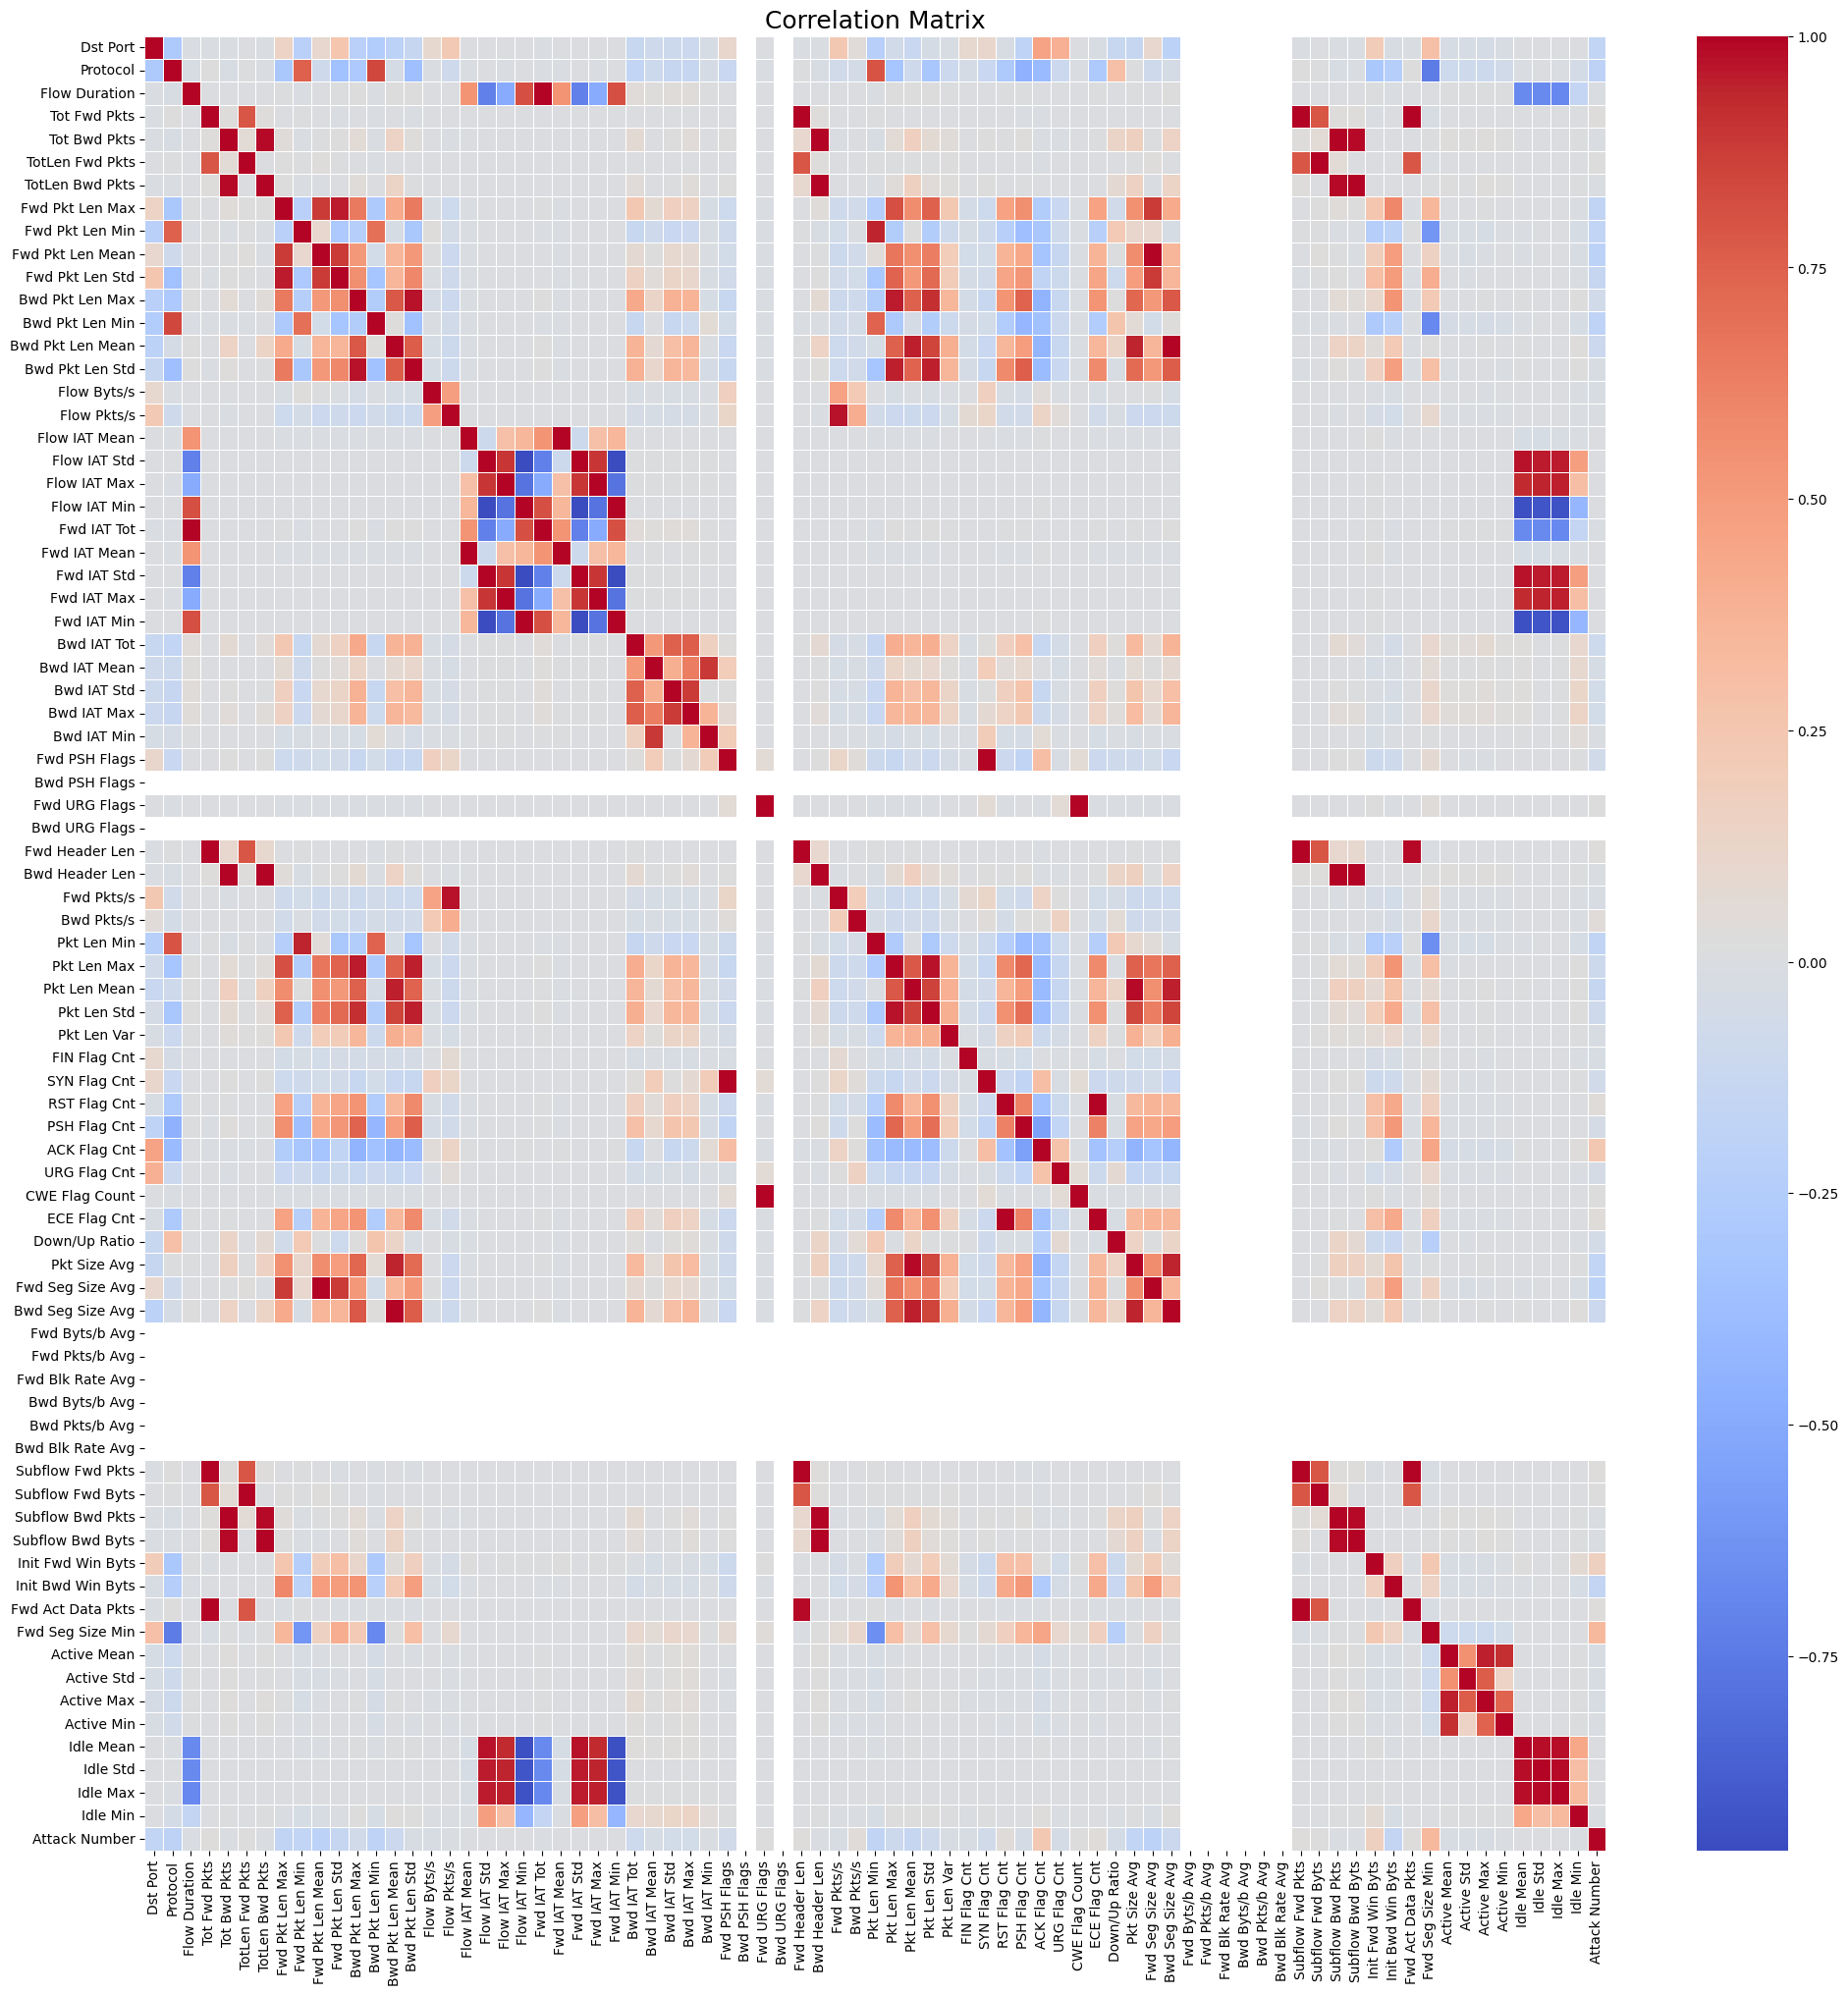

In [43]:
corr = df.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)

fig, ax = plt.subplots(figsize = (24, 24))
sns.heatmap(corr, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()

In [44]:
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)].index.tolist()
# ordenador por valor absoluto
pos_corr_features.sort(key = lambda x: abs(corr.loc[x, 'Attack Number']), reverse = True)

print("Features with positive correlation with 'Attack Number':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'Attack Number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value))

print(f'Number of considerable important features: {len(pos_corr_features)}')

Features with positive correlation with 'Attack Number':

1.  Fwd Seg Size Min         :0.34
2.  ACK Flag Cnt             :0.24
3.  Init Fwd Win Byts        :0.17
4.  Bwd Pkts/s               :0.05
5.  RST Flag Cnt             :0.04
6.  ECE Flag Cnt             :0.04
7.  Tot Fwd Pkts             :0.03
8.  Fwd Header Len           :0.03
9.  Subflow Fwd Pkts         :0.03
10. Fwd Act Data Pkts        :0.03
11. TotLen Fwd Pkts          :0.02
12. Fwd URG Flags            :0.02
13. CWE Flag Count           :0.02
14. Subflow Fwd Byts         :0.02
Number of considerable important features: 14


/tmp/ipykernel_2760331/2043510913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)


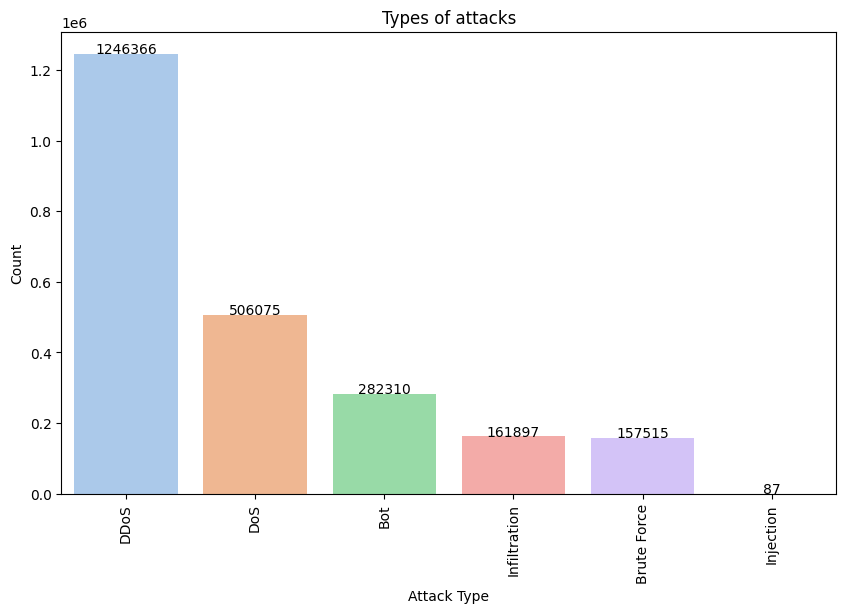

In [46]:
# Different 'Attack Type' in the main dataset excluding 'BENIGN'
attacks = df.loc[df['Attack Type'] != 'BENIGN']

plt.figure(figsize = (10, 6))
ax = sns.countplot(x = 'Attack Type', data = attacks, palette = 'pastel', order = attacks['Attack Type'].value_counts().index)
plt.title('Types of attacks')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation = 90)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2, p.get_height() + 1000), ha = 'center')

plt.show()

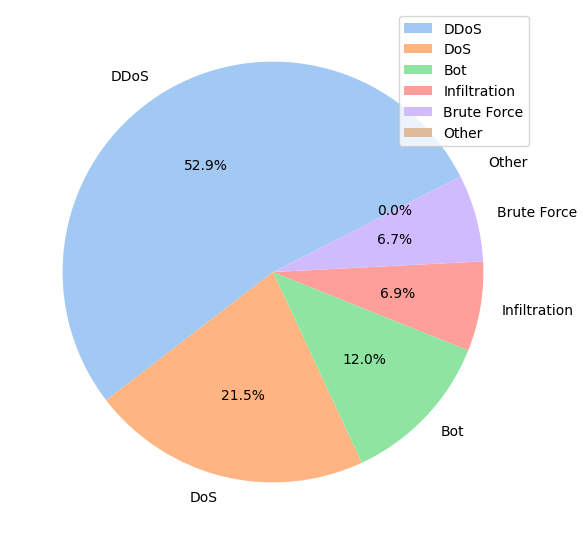

In [47]:
# Calculate attack type distribution
attack_counts = attacks['Attack Type'].value_counts()
threshold = 0.005
percentages = attack_counts / attack_counts.sum()
small_slices = percentages[percentages < threshold].index.tolist()

# Combine small categories into 'Other'
if small_slices:
    other_sum = attack_counts[small_slices].sum()
    attack_counts = attack_counts.drop(small_slices)
    attack_counts['Other'] = other_sum

# Plot settings
sns.set_palette('pastel')
plt.figure(figsize=(6,6))

# Improved labels with clearer formatting
explode = [0.05 if label == 'Other' else 0 for label in attack_counts.index]
plt.pie(
    attack_counts.values, 
    labels=attack_counts.index, 
    autopct='%1.1f%%', 
    textprops={'fontsize': 10},
    explode=explode,
    startangle=387
)

# Title and legend adjustments
plt.legend(attack_counts.index, loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('attack_distribution.png',dpi=500)
plt.show()


### 5. Data preprocessing

In [48]:
# For improving performance and reduce memory-related errors
old_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df.columns:
    col_type = df[col].dtype
    if col_type != object:
        c_min = df[col].min()
        c_max = df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)

new_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

# Calculating percentage reduction in memory usage
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Initial memory usage: 9884.49 MB
Final memory usage: 5123.06 MB
Reduced memory usage: 48.17%


In [49]:
# Dropping columns with only one unique value
num_unique = df.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = df[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg',
       'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg',
       'Bwd Blk Rate Avg'],
      dtype='object')

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15799748 entries, 0 to 16232942
Data columns (total 73 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Dst Port           int32         
 1   Protocol           float32       
 2   Timestamp          datetime64[ns]
 3   Flow Duration      float32       
 4   Tot Fwd Pkts       float32       
 5   Tot Bwd Pkts       float32       
 6   TotLen Fwd Pkts    float32       
 7   TotLen Bwd Pkts    float32       
 8   Fwd Pkt Len Max    float32       
 9   Fwd Pkt Len Min    float32       
 10  Fwd Pkt Len Mean   float32       
 11  Fwd Pkt Len Std    float32       
 12  Bwd Pkt Len Max    float32       
 13  Bwd Pkt Len Min    float32       
 14  Bwd Pkt Len Mean   float32       
 15  Bwd Pkt Len Std    float32       
 16  Flow Byts/s        float32       
 17  Flow Pkts/s        float32       
 18  Flow IAT Mean      float32       
 19  Flow IAT Std       float32       
 20  Flow IAT Max       float32 

In [51]:
# save only numerical data
attacks = data['Attack Type']
data = data.select_dtypes(include = ['float32', 'int32'])

#### PCA

In [52]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler

features = data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

from sklearn.decomposition import IncrementalPCA

size = len(features.columns) // 2
ipca = IncrementalPCA(n_components = size, batch_size = 500)
for batch in np.array_split(scaled_features, len(features) // 500):
    ipca.partial_fit(batch)

print(f'information retained: {sum(ipca.explained_variance_ratio_):.2%}')

transformed_features = ipca.transform(scaled_features)
new_data_pca = pd.DataFrame(transformed_features, columns = [f'PC{i+1}' for i in range(size)])
new_data_pca['Attack Type'] = attacks.values

new_data_pca

information retained: 99.45%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Attack Type
0,-2.509368,0.203272,-0.039310,-0.140706,0.322799,0.671007,1.305862,0.419530,-0.803705,0.299363,...,0.159135,-0.133117,0.011667,0.225158,-0.812696,-1.553432,-1.296031,-1.512617,0.555685,BENIGN
1,-2.516422,0.144865,-0.065418,-0.166519,0.270772,0.324362,0.284526,0.550880,-0.958530,0.308537,...,0.170621,-0.092107,-0.219102,0.363457,-0.836991,-1.549648,-1.343860,-1.547885,0.578635,BENIGN
2,-0.966698,0.018119,2.855750,8.034159,-7.327015,-1.665551,1.940824,0.391759,5.465520,-3.993218,...,7.561811,6.082503,1.289755,1.258285,0.786977,-0.805557,-0.447590,0.275247,1.535531,BENIGN
3,-2.516422,0.144865,-0.065418,-0.166519,0.270772,0.324362,0.284526,0.550880,-0.958530,0.308537,...,0.170621,-0.092107,-0.219102,0.363457,-0.836991,-1.549648,-1.343860,-1.547885,0.578635,BENIGN
4,-2.511668,0.285839,-0.051204,-0.151460,0.298562,0.506276,0.851430,0.387441,-0.882854,0.301419,...,0.164956,-0.113633,-0.124680,0.308024,-0.822520,-1.543230,-1.321139,-1.526074,0.561351,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15799743,-2.427846,0.203337,-0.655857,-1.795190,1.610823,-0.459570,0.066752,0.879211,-0.523421,-0.337499,...,-0.328718,0.796270,0.053019,0.327983,0.828248,-0.018273,0.200507,0.001604,-0.142658,BENIGN
15799744,-2.705072,0.006397,-0.425861,-1.205846,1.217289,-0.110443,-0.015562,-0.001755,-0.476788,-0.025604,...,-0.210688,0.755842,0.075233,-0.066842,0.503496,-0.052264,-0.082005,-0.148183,-0.075134,BENIGN
15799745,-2.153055,-0.006421,0.857824,2.413961,-1.876197,-0.142057,-0.085075,0.023585,0.223195,-0.087272,...,-0.179327,-0.154124,-0.013190,0.004965,0.011276,-0.030663,-0.012176,0.155531,-0.023546,BENIGN
15799746,4.534169,-0.050910,-0.488450,-0.797236,-0.255090,-1.397870,0.448083,0.178389,-0.085633,-0.530006,...,-0.670316,0.710851,0.154866,0.052212,-0.044953,0.222755,0.029873,-0.015949,0.051351,BENIGN


In [33]:
# select k best features
from sklearn.feature_selection import SelectKBest, f_classif

features = data
target = attacks

k = 20
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_20 = data[selected_features]
new_data_k_20['Attack Type'] = attacks.values

k = 40
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_40 = data[selected_features]
new_data_k_40['Attack Type'] = attacks.values

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/tmp/ipykernel_2705846/1773033171.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_k_20['Attack Type'] = attacks.values


Selected Features: Index(['Dst Port', 'Flow Duration', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Flow Bytes/s',
       'Flow Packets/s', 'Fwd IAT Total', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'FIN Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Fwd Segment Size Avg', 'Fwd Seg Size Min',
       'Active Mean', 'Active Std', 'Active Max', 'Attack Number'],
      dtype='object')
Selected Features: Index(['Dst Port', 'Flow Duration', 'Total Length of Fwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Total',
       'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Packets/s', 'Bwd Packets/s',
    

/home/alara/CiberIA_O1/env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/tmp/ipykernel_2705846/1773033171.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_k_40['Attack Type'] = attacks.values
